## ITS Modeling

### Create copy of final df for modeling

In [16]:
# Create df for modeling
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# sort
final = pd.read_csv('teamb_final_data.csv')
final['datetime'] = pd.to_datetime(final['datetime'])
final = final.sort_values('datetime')

# aggregate monthly extreme outcome rates
final['month'] = final['datetime'].dt.to_period('M')
monthly = final.groupby('month')['extreme_cases'].mean().reset_index()

### Standard ITS Model

                            OLS Regression Results                            
Dep. Variable:          extreme_cases   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     56.60
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.85e-18
Time:                        13:00:47   Log-Likelihood:                 341.61
No. Observations:                  72   AIC:                            -675.2
Df Residuals:                      68   BIC:                            -666.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0043      0.001      5.817

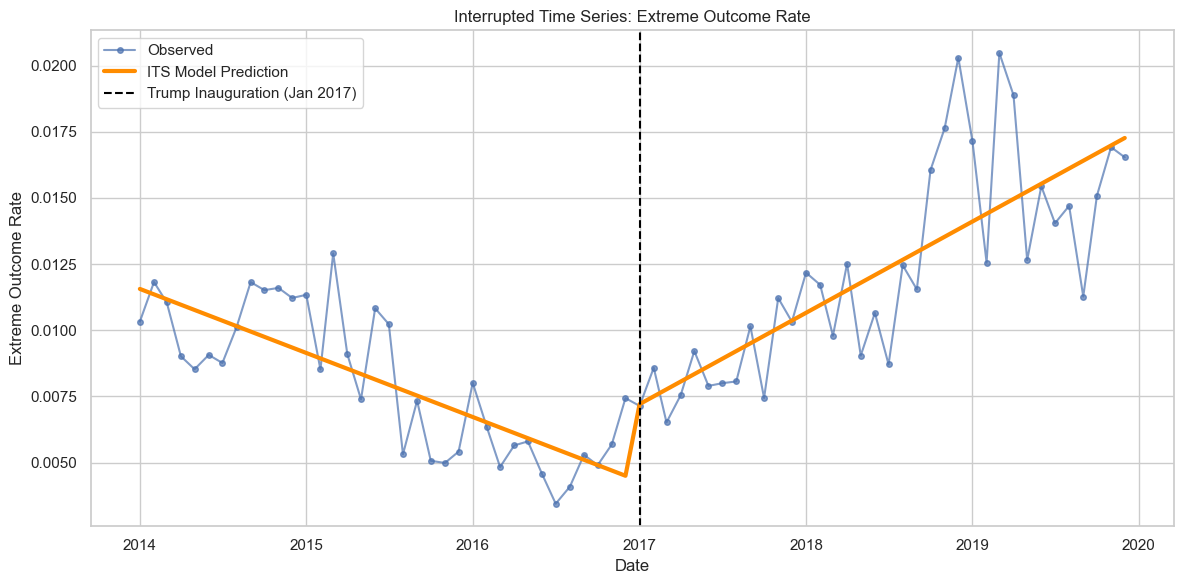

In [17]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- Ensure month column is datetime ---
monthly['month'] = monthly['month'].dt.to_timestamp()

# --- Define intervention date ---
intervention = pd.to_datetime("2017-01-01")

# --- Create centered time variable ---
monthly['time_centered'] = (monthly['month'] - intervention).dt.days / 30

# --- Create Trump indicator ---
monthly['trump'] = (monthly['month'] >= intervention).astype(int)

# --- Create interaction term for slope change ---
monthly['time_trump'] = monthly['time_centered'] * monthly['trump']

# --- Fit interrupted time series model ---
model = smf.ols(
    'extreme_cases ~ time_centered + trump + time_trump',
    data=monthly
).fit()

print(model.summary())

# --- Generate model predictions ---
monthly['predicted'] = model.predict(monthly)

# --- Plot observed vs predicted ---
plt.figure(figsize=(12,6))

plt.plot(monthly['month'], monthly['extreme_cases'],
         marker='o', markersize=4,
         linewidth=1.5,
         alpha=0.7,
         label="Observed")

plt.plot(monthly['month'], monthly['predicted'],
         linewidth=3,
         color='darkorange',
         label="ITS Model Prediction")

plt.axvline(intervention, color='black', linestyle='--', label='Trump Inauguration (Jan 2017)')

plt.title("Interrupted Time Series: Extreme Outcome Rate")
plt.xlabel("Date")
plt.ylabel("Extreme Outcome Rate")

plt.legend()
plt.tight_layout()
plt.savefig('its_graph.png')
plt.show()

### ITS Model with Counterfactual

                            OLS Regression Results                            
Dep. Variable:          extreme_cases   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     56.60
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.85e-18
Time:                        13:00:57   Log-Likelihood:                 341.61
No. Observations:                  72   AIC:                            -675.2
Df Residuals:                      68   BIC:                            -666.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.0043      0.001      5.817

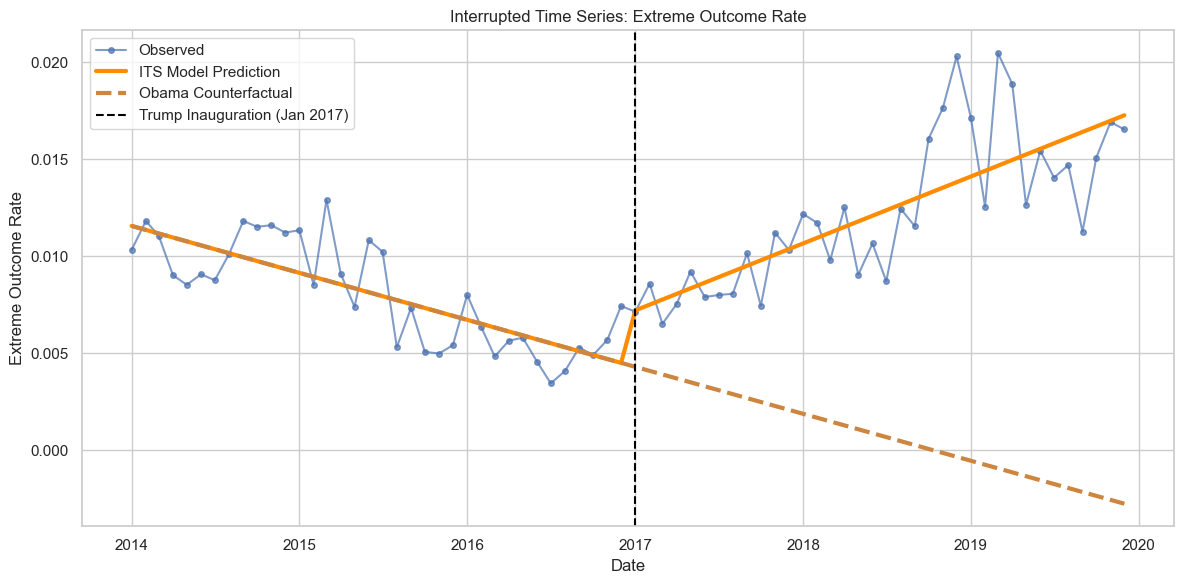

In [18]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- Ensure month column is datetime ---
monthly['month'] = pd.to_datetime(monthly['month'])

# --- Intervention date ---
intervention = pd.to_datetime("2017-01-01")

# --- Center time at intervention ---
monthly['time_centered'] = (monthly['month'] - intervention).dt.days / 30

# --- Trump indicator ---
monthly['trump'] = (monthly['month'] >= intervention).astype(int)

# --- Slope change term ---
monthly['time_trump'] = monthly['time_centered'] * monthly['trump']

# --- Fit interrupted time series model ---
model = smf.ols(
    'extreme_cases ~ time_centered + trump + time_trump',
    data=monthly
).fit()

print(model.summary())

# --- Model predictions (actual Trump world) ---
monthly['predicted'] = model.predict(monthly)

# --- Create Obama counterfactual ---
monthly_cf = monthly.copy()
monthly_cf['trump'] = 0
monthly_cf['time_trump'] = 0

monthly['obama_counterfactual'] = model.predict(monthly_cf)

# --- Plot ---
plt.figure(figsize=(12,6))

# observed data
plt.plot(monthly['month'], monthly['extreme_cases'],
         marker='o', markersize=4,
         linewidth=1.5,
         alpha=0.7,
         label="Observed")

# model fit
plt.plot(monthly['month'], monthly['predicted'],
         linewidth=3,
         color='darkorange',
         label="ITS Model Prediction")

# obama counterfactual
plt.plot(monthly['month'], monthly['obama_counterfactual'],
         linestyle="--",
         linewidth=3,
         color='peru',
         label="Obama Counterfactual")

# intervention line
plt.axvline(intervention, color='black', linestyle='--', label='Trump Inauguration (Jan 2017)')

plt.title("Interrupted Time Series: Extreme Outcome Rate")
plt.xlabel("Date")
plt.ylabel("Extreme Outcome Rate")

plt.legend()
plt.tight_layout()
plt.savefig('its_graph_counterfactual.png')
plt.show()

In [20]:
# Calculate final difference
monthly['policy_effect'] = monthly['predicted'] - monthly['obama_counterfactual']
final_effect = monthly['policy_effect'].iloc[-1]
print(final_effect)

0.020023266323865092


### Load Data for ITS with Race Interaction

In [21]:
# 1. Load and clean raw data
import pandas as pd 
import numpy as np 
final = pd.read_csv('teamb_final_data.csv') 

# Convert datetime and sort 
final['datetime'] = pd.to_datetime(final['datetime']) 
final = final.sort_values('datetime') 

# 2. Create time variables 
# Monthly period 
final['month'] = final['datetime'].dt.to_period('M') 

# 3. Create race variable (from dummies) 
final['race'] = np.select( [ final['subject_race_white'] == 1, final['subject_race_black'] == 1, final['subject_race_hispanic'] == 1, final['subject_race_other'] == 1 ], ['white', 'black', 'hispanic', 'other'], default='unknown' ) 
# (optional) drop unknown if you don’t want it 
final = final[~final['race'].isin(['other', 'unknown'])]

# 4. Aggregate to month × race level 
monthly = final.groupby(['month', 'race']).agg({ 'extreme_cases': 'mean' # proportion of extreme outcomes 
                                               }).reset_index() 

# 5. Convert month to timestamp (for plotting + modeling)
monthly['month'] = monthly['month'].dt.to_timestamp()

### ITS Model with Race Interaction

In [22]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- Define intervention date ---
intervention = pd.to_datetime("2017-01-01")

# --- Create centered time variable ---
monthly['time_centered'] = (monthly['month'] - intervention).dt.days / 30

# --- Create Trump indicator ---
monthly['trump'] = (monthly['month'] >= intervention).astype(int)

# --- Create interaction term for slope change ---
monthly['time_trump'] = monthly['time_centered'] * monthly['trump']

# --- Fit interrupted time series model ---
model = smf.ols(
    'extreme_cases ~ time_centered * C(race) + trump * C(race) + time_trump * C(race)',
    data=monthly
).fit()

print(model.summary())

# --- Generate model predictions ---
monthly['predicted'] = model.predict(monthly)

                            OLS Regression Results                            
Dep. Variable:          extreme_cases   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     27.09
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.98e-34
Time:                        13:02:22   Log-Likelihood:                 919.47
No. Observations:                 216   AIC:                            -1815.
Df Residuals:                     204   BIC:                            -1774.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Plot of Observed/Predicted Extreme Outcomes by Race

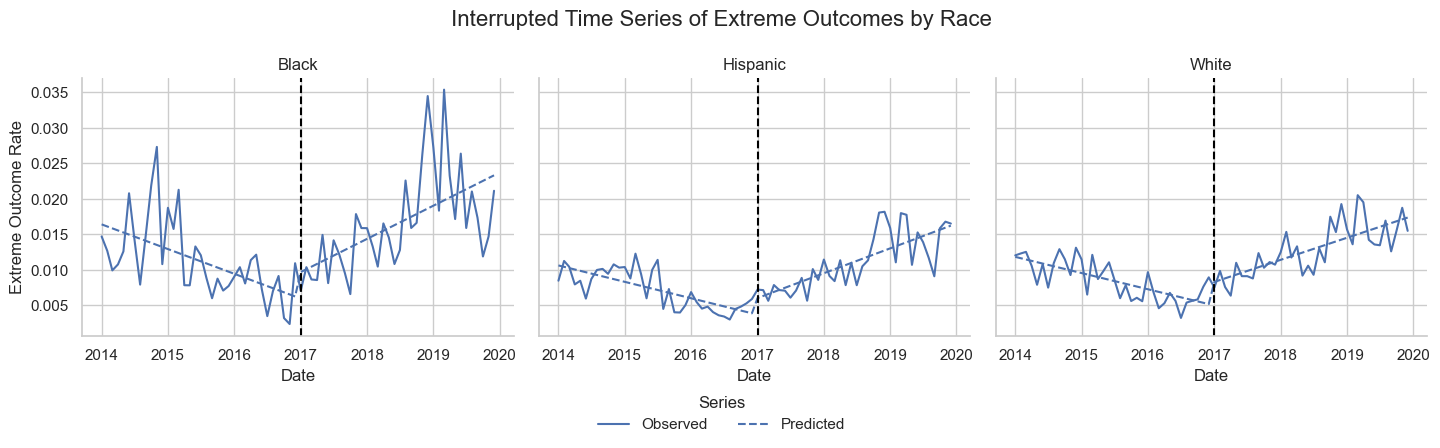

In [23]:
import seaborn as sns

monthly['race'] = monthly['race'].str.capitalize()
sns.set(style="whitegrid")

g = sns.FacetGrid(monthly, col="race", col_wrap=3, height=4, sharey=True)
g.map_dataframe(sns.lineplot, x="month", y="extreme_cases", label="Observed")
g.map_dataframe(sns.lineplot, x="month", y="predicted", linestyle="--", label="Predicted")

for ax in g.axes.flatten():
    ax.axvline(intervention, color='black', linestyle='--')

g.set_axis_labels("Date", "Extreme Outcome Rate")
g.set_titles(template="{col_name}", 
             col_template=lambda x: x.upper())
g.add_legend(title="Series", bbox_to_anchor=(0.5, 0.05), loc='upper center', ncol=2)

g.fig.suptitle("Interrupted Time Series of Extreme Outcomes by Race", fontsize=16)
g.fig.subplots_adjust(top=0.9)  # leave space for the title

plt.tight_layout()
plt.savefig('its_race.png')
plt.show()

### Plot Predicted Outcomes by Race

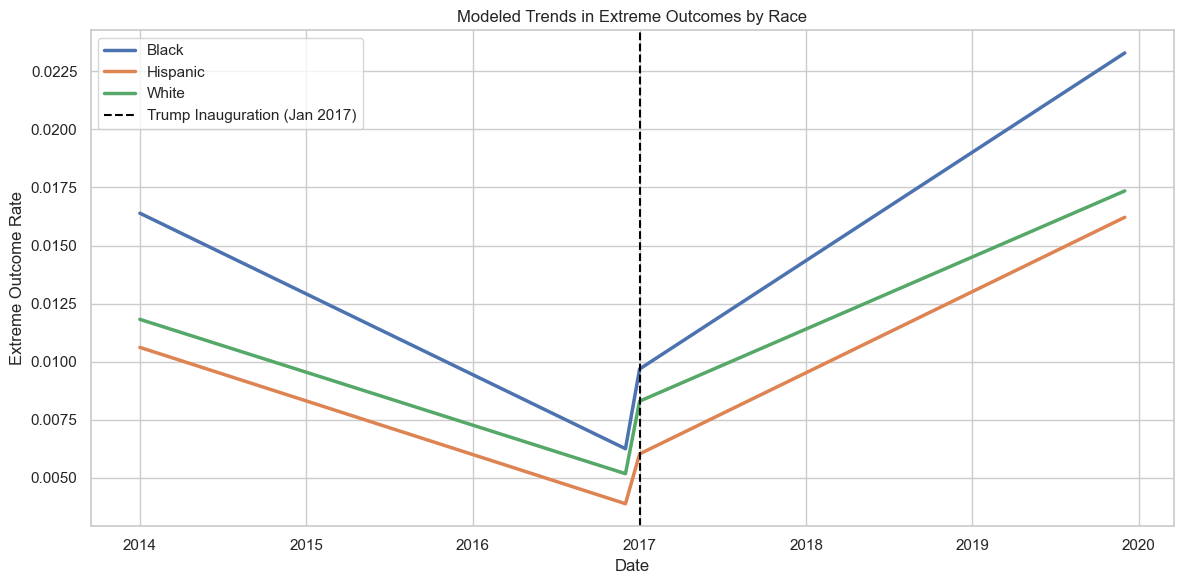

In [24]:
plt.figure(figsize=(12,6))

for r in monthly['race'].unique():
    subset = monthly[monthly['race'] == r]
    plt.plot(subset['month'], subset['predicted'], linewidth=2.5, label=r)

plt.axvline(intervention, color='black', linestyle='--', label='Trump Inauguration (Jan 2017)')

plt.title("Modeled Trends in Extreme Outcomes by Race")
plt.xlabel("Date")
plt.ylabel("Extreme Outcome Rate")

plt.legend()
plt.tight_layout()
plt.savefig('its_race_predicted.png')
plt.show()